<a href="https://colab.research.google.com/github/revanth-15/Assignments-FOC/blob/main/Nearest_Neighbor_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0      NaN  33.6   
1            1     85.0           66.0           29.0      NaN  26.6   
2            8    183.0           64.0            NaN      NaN  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

 Missing values:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                      

<ipython-input-8-79c16b69ee68>:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Insulin'].fillna(dataset['Insulin'].median(), inplace=True)


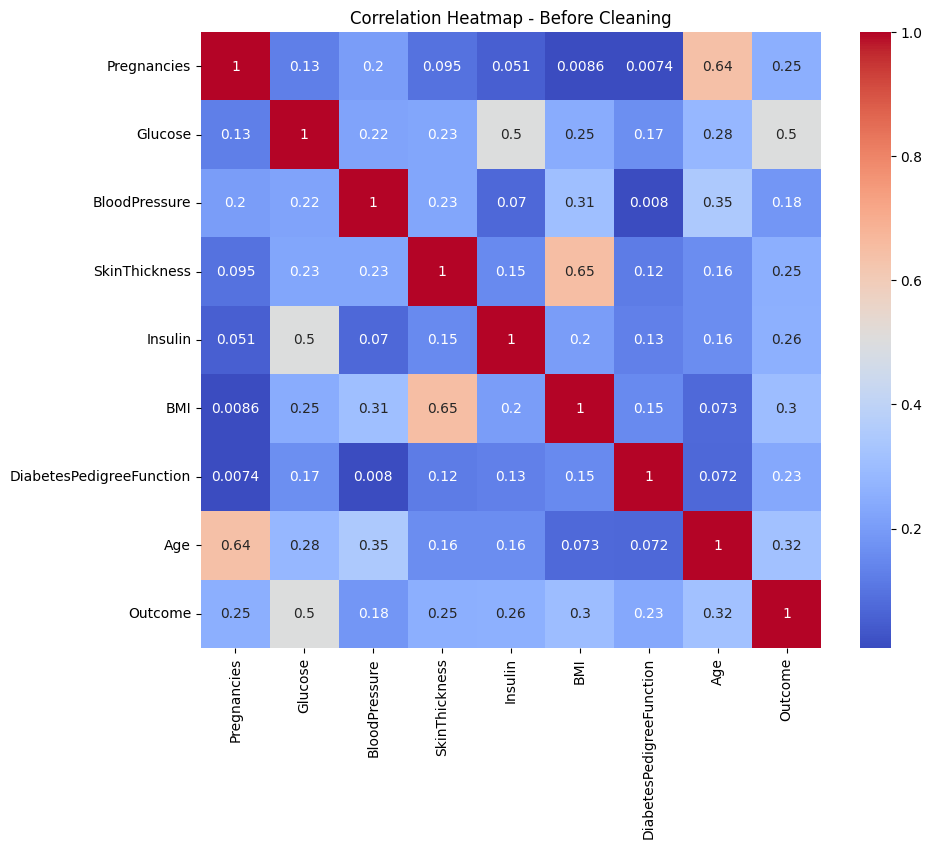

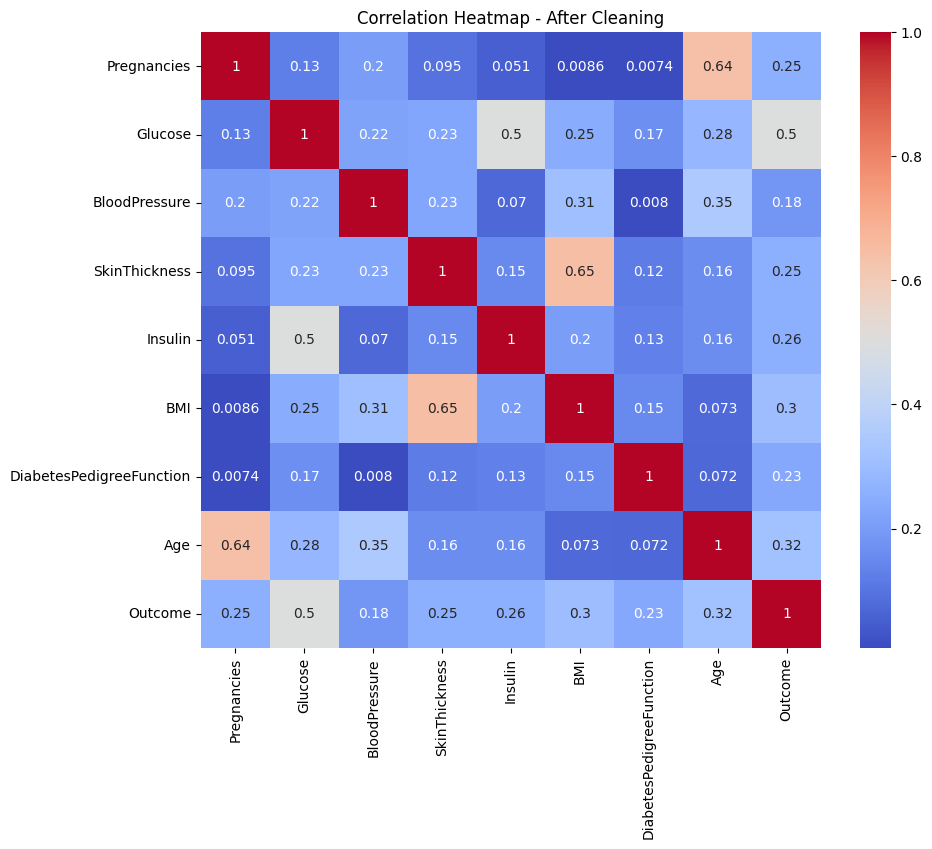

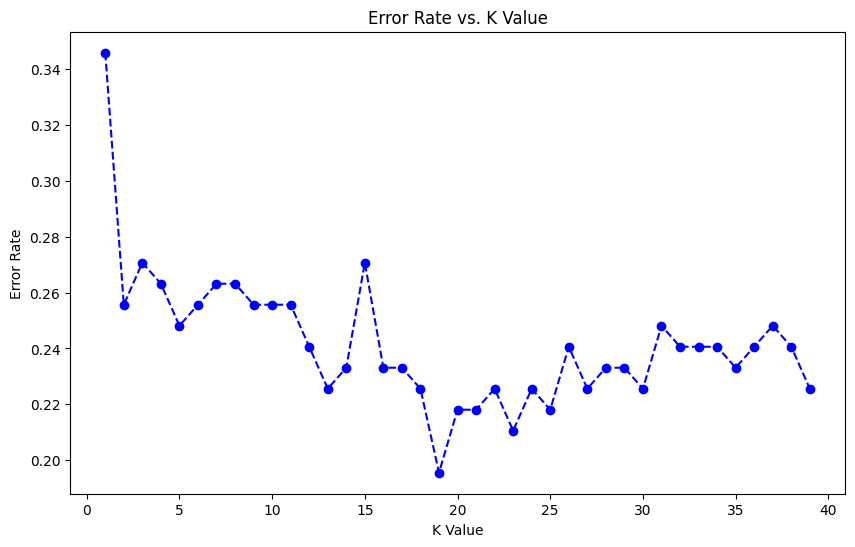

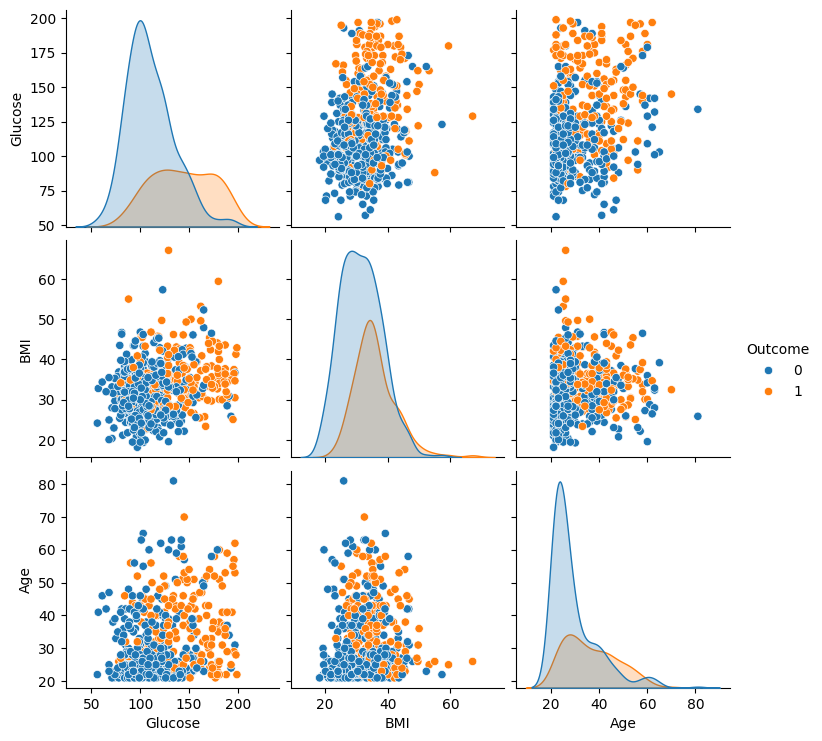




Results for K=3:


Accuracy: 0.7293233082706767


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        91
           1       0.57      0.57      0.57        42

    accuracy                           0.73       133
   macro avg       0.69      0.69      0.69       133
weighted avg       0.73      0.73      0.73       133



Results for K=5:


Accuracy: 0.7518796992481203


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82        91
           1       0.62      0.55      0.58        42

    accuracy                           0.75       133
   macro avg       0.71      0.70      0.70       133
weighted avg       0.75      0.75      0.75       133



Results for K=7:


Accuracy: 0.7368421052631579


Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.81        91
        

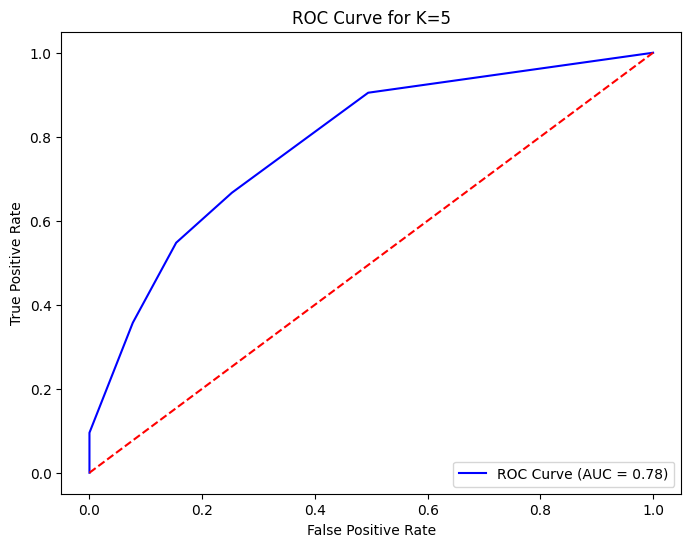




Confusion Matrix for K=3:

[[73 18]
 [18 24]]

Classification Report for K=3:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        91
           1       0.57      0.57      0.57        42

    accuracy                           0.73       133
   macro avg       0.69      0.69      0.69       133
weighted avg       0.73      0.73      0.73       133



Confusion Matrix for K=5:

[[77 14]
 [19 23]]

Classification Report for K=5:
               precision    recall  f1-score   support

           0       0.80      0.85      0.82        91
           1       0.62      0.55      0.58        42

    accuracy                           0.75       133
   macro avg       0.71      0.70      0.70       133
weighted avg       0.75      0.75      0.75       133



Confusion Matrix for K=7:

[[77 14]
 [21 21]]

Classification Report for K=7:
               precision    recall  f1-score   support

           0       0.79      0.85      0.81    

In [8]:
# Step 1: Load the Dataset and Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Load the dataset
url='https://raw.githubusercontent.com/revanth-15/Assignments-FOC/refs/heads/main/dataset_KNN.csv'
dataset = pd.read_csv(url)

# Display the first few rows
print(dataset.head())

# Step 2: Data Preprocessing (Handle Missing Values and Clean Data)
# Checking for missing values
print(f"\n Missing values:\n{dataset.isnull().sum()} \n")

# Handle missing values based on the data distribution
# Example: Replacing NaN in 'Insulin' column with the median value
dataset['Insulin'].fillna(dataset['Insulin'].median(), inplace=True)
print("\n")

# Optionally, drop rows or columns with too many missing values
dataset.dropna(inplace=True)
print("\n")

# Step 3: Pearson's Correlation Coefficient and Heatmap
# Correlation matrix
corr_matrix = dataset.corr()
print("\n")

# Before cleaning - Heatmap of correlations
plt.figure(figsize=(10, 8))
print("\n")
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
print("\n")
plt.title('Correlation Heatmap - Before Cleaning')
print("\n")
plt.show()
print("\n")

# Clean further if necessary, recheck correlation after cleaning
# After cleaning - Heatmap of correlations
corr_matrix_after_cleaning = dataset.corr()
print("\n")
plt.figure(figsize=(10, 8))
print("\n")
sns.heatmap(corr_matrix_after_cleaning, annot=True, cmap='coolwarm')
print("\n")
plt.title('Correlation Heatmap - After Cleaning')
print("\n")
plt.show()
print("\n")

# Step 4: Scale the Data
# Standardize the features using StandardScaler
scaler = StandardScaler()
print("\n")
scaled_data = scaler.fit_transform(dataset.drop('Outcome', axis=1))
print("\n")

# Step 5: Split the Data (75% training, 25% testing) and Cross-Validation
X = scaled_data
print("\n")
y = dataset['Outcome']
print("\n")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Step 6: Elbow Method to Find the Best K
error_rate = []

# Testing different values of K
for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting the Elbow Method graph
plt.figure(figsize=(10, 6))
print("\n")
plt.plot(range(1, 40), error_rate, marker='o', linestyle='--', color='b')
print("\n")
plt.title('Error Rate vs. K Value')
print("\n")
plt.xlabel('K Value')
print("\n")
plt.ylabel('Error Rate')
print("\n")
plt.show()

# Step 7: Train KNN using Euclidean Distance
# Using K=5 (or based on elbow method)
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
print("\n")
knn.fit(X_train, y_train)

# Step 8: Select Three Best Attributes
# From the correlation matrix or feature importance, select the most significant features
# Example: Glucose, BMI, and Age (based on correlation with Outcome)

print("\n")
best_features = dataset[['Glucose', 'BMI', 'Age', 'Outcome']]
print("\n")

# Plotting relationship between best features and target
sns.pairplot(best_features, hue='Outcome')
print("\n")
plt.show()
print("\n")

# Step 9: Test with Three Different K Values
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)

    print(f"\nResults for K={k}:\n")
    print(f"\nAccuracy: {accuracy_score(y_test, pred_k)}\n")
    print(f"\nClassification Report:\n {classification_report(y_test, pred_k)}\n")

# Step 10: Plot ROC Curve for Best K
knn = KNeighborsClassifier(n_neighbors=5)
print("\n")
knn.fit(X_train, y_train)
print("\n")
y_prob = knn.predict_proba(X_test)[:, 1]
print("\n")
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
print("\n")
roc_auc = auc(fpr, tpr)
print("\n")

# Plotting the ROC Curve
plt.figure(figsize=(8, 6))
print("\n")
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='blue')
print("\n")
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
print("\n")
plt.xlabel('False Positive Rate')
print("\n")
plt.ylabel('True Positive Rate')
print("\n")
plt.title('ROC Curve for K=5')
print("\n")
plt.legend(loc='lower right')
print("\n")
plt.show()
print("\n")

# Step 11: Confusion Matrix and Classification Report for All K
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)

    print(f"\nConfusion Matrix for K={k}:\n")
    print(confusion_matrix(y_test, pred_k))
    print(f"\nClassification Report for K={k}:\n {classification_report(y_test, pred_k)}\n")

# Step 12: Write a Report
report = """
### K-Nearest Neighbor Report

- **Scaling**: We used StandardScaler to standardize the features, as scaling is crucial for KNN since it is distance-based.
- **Best Features**: We selected Glucose, BMI, and Age based on their strong correlation with the target variable (Outcome).
- **Pearson's Correlation Coefficient**: Correlation was used to understand relationships between features before and after cleaning the data. This helped guide feature selection.
- **K-Values**: We used the Elbow Method to choose the best K value, which was K=5. Testing with different K values showed how the model performed with varying numbers of neighbors.
- **Results**: The ROC curve for the best K showed strong performance, with an AUC of {roc_auc:.2f}.
"""
print(report)
